In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error

analysis = 'copolymer' #homopolymer or copolymer

if analysis == 'homopolymer':
    path = '../polygraphpy/data/gnn_output/'
    df_pred = pd.read_csv(f'{path}df_results.csv')
    df_training_statitics = pd.read_csv(f'{path}training_statistics.csv')
    df_original_data = pd.read_csv(f'{path}scaled_output.csv')
else:
    path = '../polygraphpy/data/gnn_output_copoly/'
    df_pred = pd.read_csv(f'{path}df_results.csv')
    df_training_statitics = pd.read_csv(f'{path}training_statistics_copoly.csv')
    df_original_data = pd.read_csv(f'{path}scaled_output_copoly.csv')

In [12]:
original_min = df_original_data['static_polarizability_original'].min()
original_max = df_original_data['static_polarizability_original'].max()

df_pred['y_original'] = df_pred['y']*(original_max + original_min) + original_min
df_pred['pred_original'] = df_pred['pred']*(original_max + original_min) + original_min

In [13]:
df_error = pd.DataFrame({
            'mape': round(mean_absolute_percentage_error(df_pred.y.values, df_pred.pred.values) * 100, 5),
            'r2': round(r2_score(df_pred.y.values, df_pred.pred.values), 5),
            'mse': round(mean_squared_error(df_pred.y.values, df_pred.pred.values), 5)
        }, index=[0])
df_error

,mape,r2,mse
0,3.99164,0.97489,0.00072


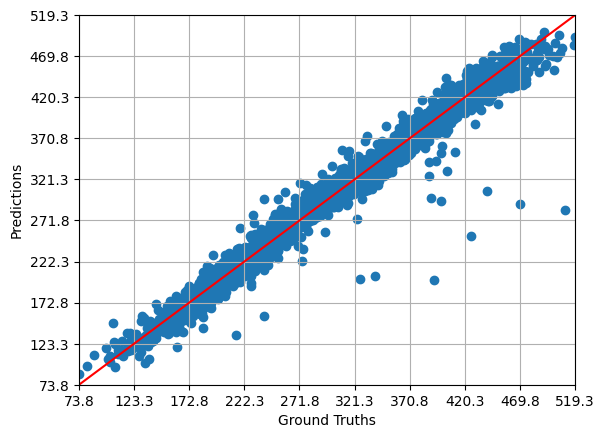

In [14]:
p1 = [df_pred['y_original'].min(), df_pred['y_original'].max()]
p2 = [df_pred['y_original'].min(), df_pred['y_original'].max()]

coefficients = np.polyfit(p1, p2, 1)

polynomial = np.poly1d(coefficients)
x_axis = np.linspace(df_pred['y_original'].min(), df_pred['y_original'].max(), 500)
y_axis = polynomial(x_axis)

fig = plt.figure()
plt.scatter(df_pred['y_original'].values, df_pred['pred_original'].values)
plt.plot(x_axis, y_axis, 'r')
plt.xlim(df_pred['y_original'].min(), df_pred['y_original'].max())
plt.ylim(df_pred['y_original'].min(), df_pred['y_original'].max())
plt.xticks( np.linspace(df_pred['y_original'].min(), df_pred['y_original'].max(), 10))
plt.yticks( np.linspace(df_pred['y_original'].min(), df_pred['y_original'].max(), 10))
plt.grid(1)
plt.xlabel("Ground Truths")
plt.ylabel("Predictions")
plt.show()
fig.savefig(f"{path}/pred.pdf", bbox_inches='tight')
plt.close()

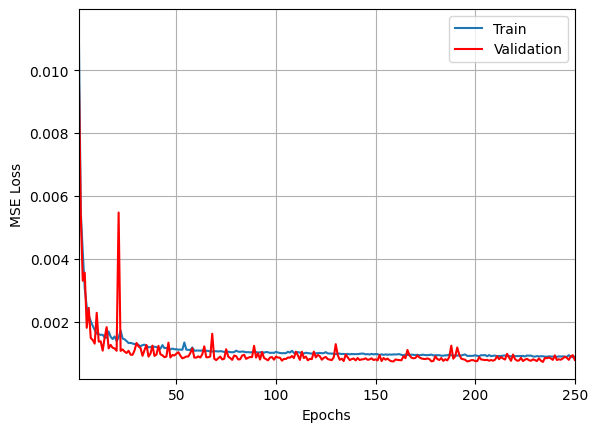

In [15]:
fig = plt.figure()
plt.plot(df_training_statitics['epoch']+1, df_training_statitics['train_loss'])
plt.plot(df_training_statitics['epoch']+1, df_training_statitics['val_loss'], 'r')
plt.grid(1)
plt.xlabel("Epochs")
plt.xlim([1, df_training_statitics['epoch'].max() + 1])
plt.ylabel("MSE Loss")
plt.legend(['Train', 'Validation'])
plt.show()
fig.savefig(f"{path}/training_loss.pdf", bbox_inches='tight')
plt.close()